## ⚽ Agrupación de Jugadores por Perfil de Producción: Gaussian Mixture Models (GMM)

C:\Users\yerayhurdra\AppData\Local\Temp\ipykernel_12680\2091409414.py:43: DtypeWarning: Columns (112) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv')


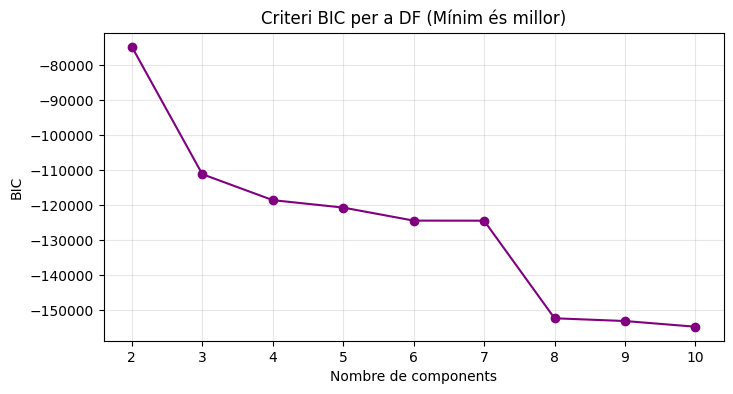

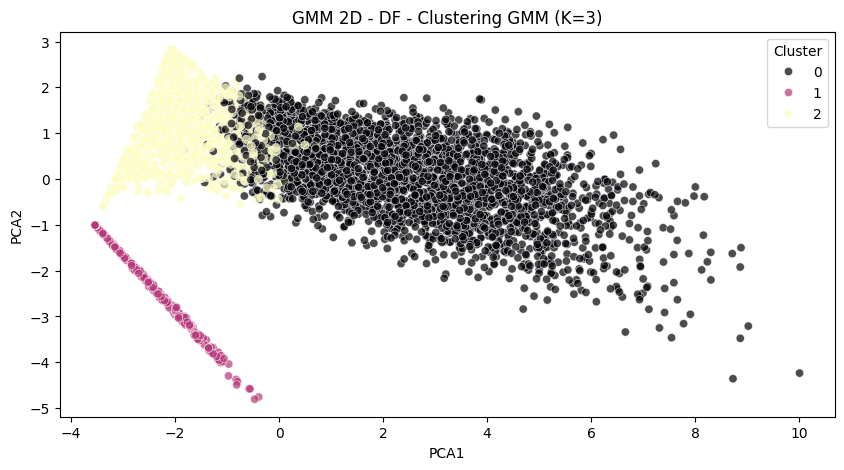

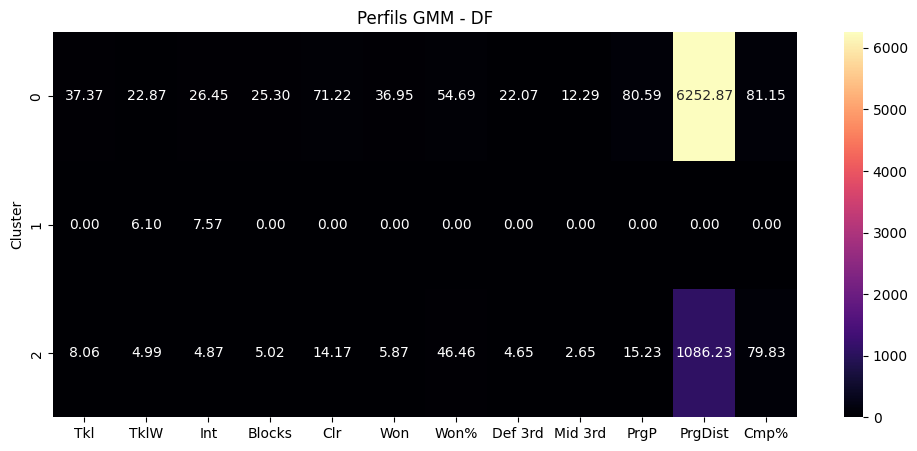

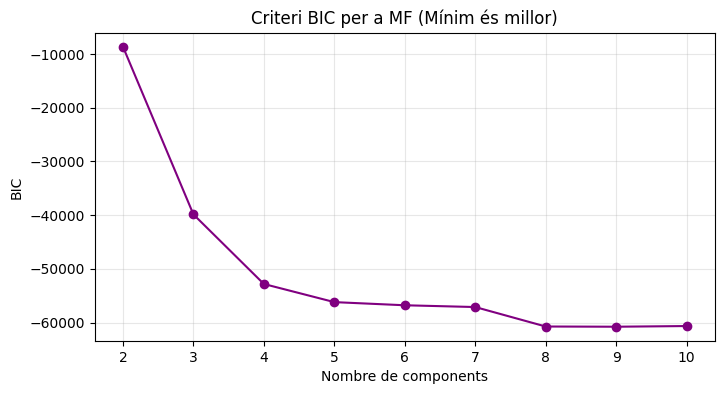

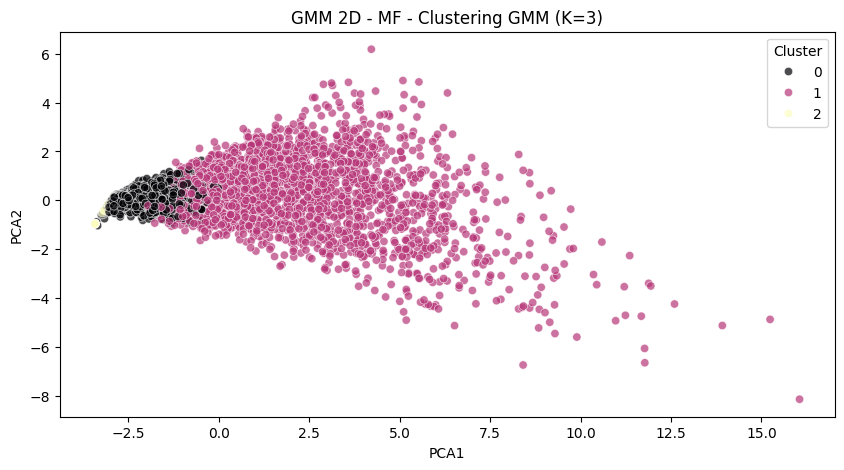

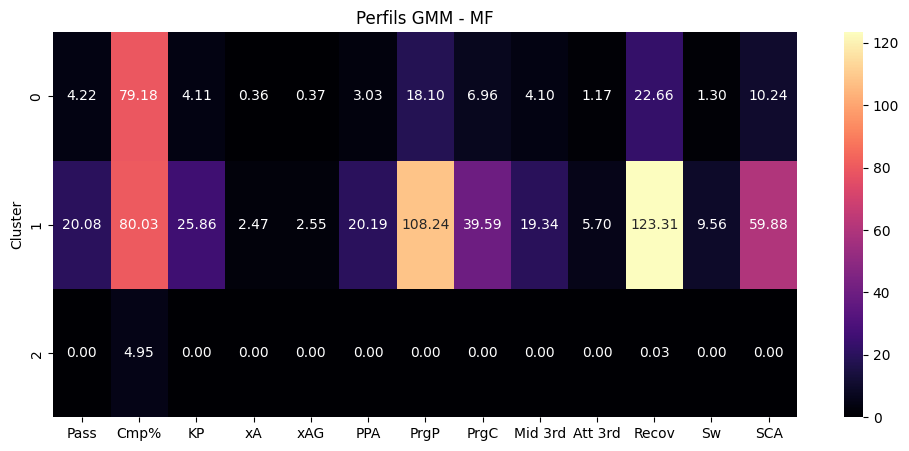

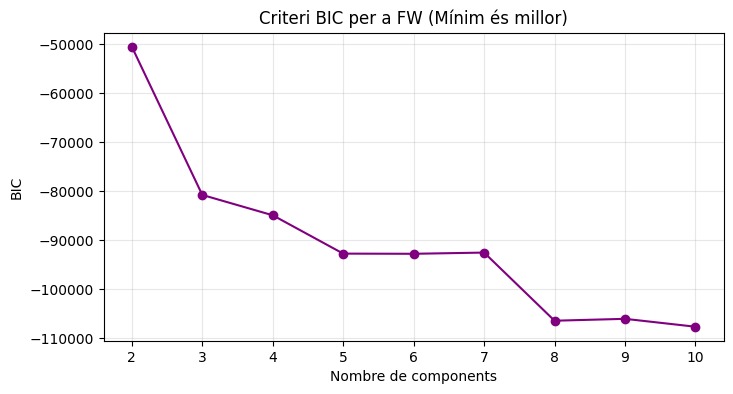

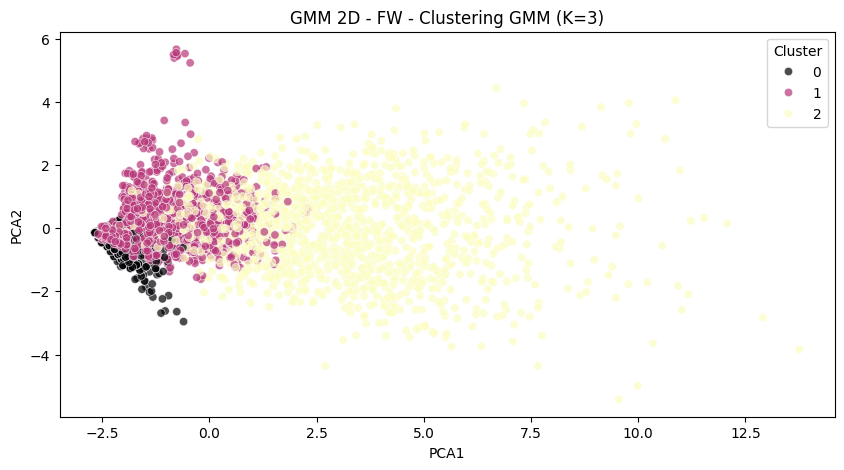

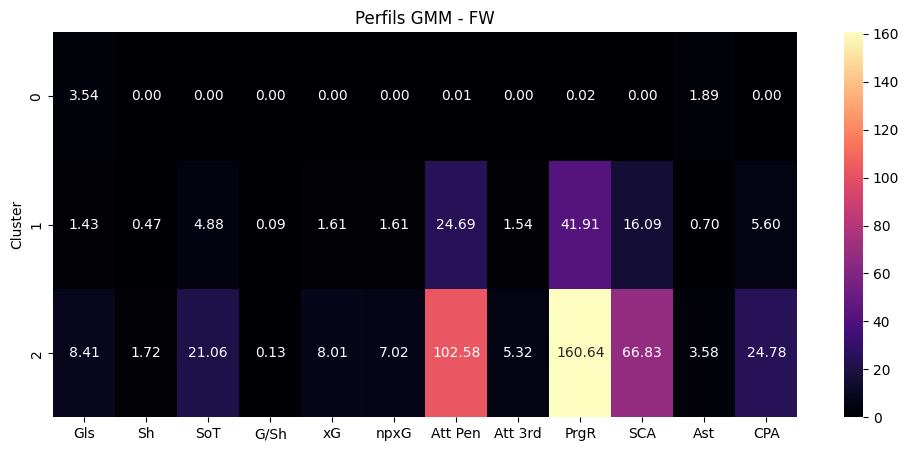

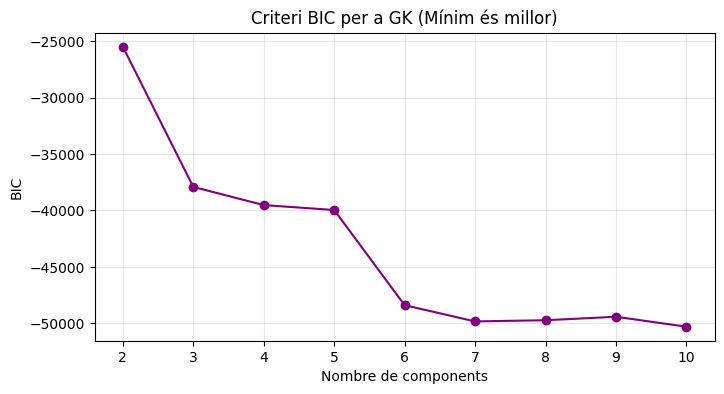

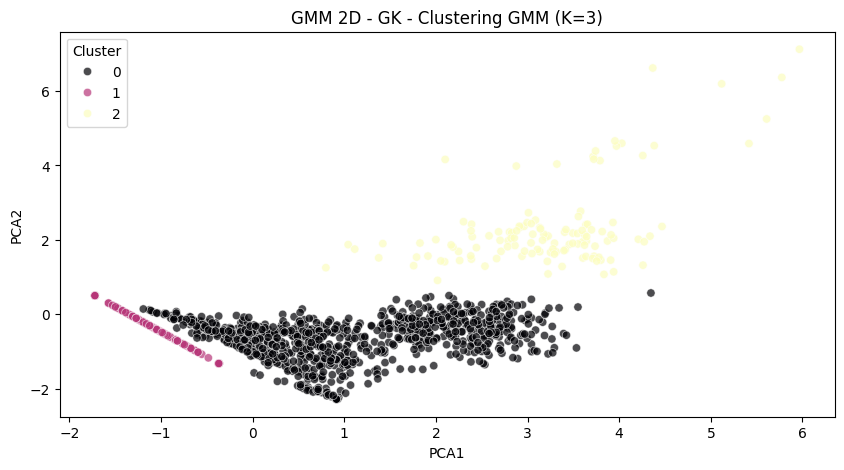

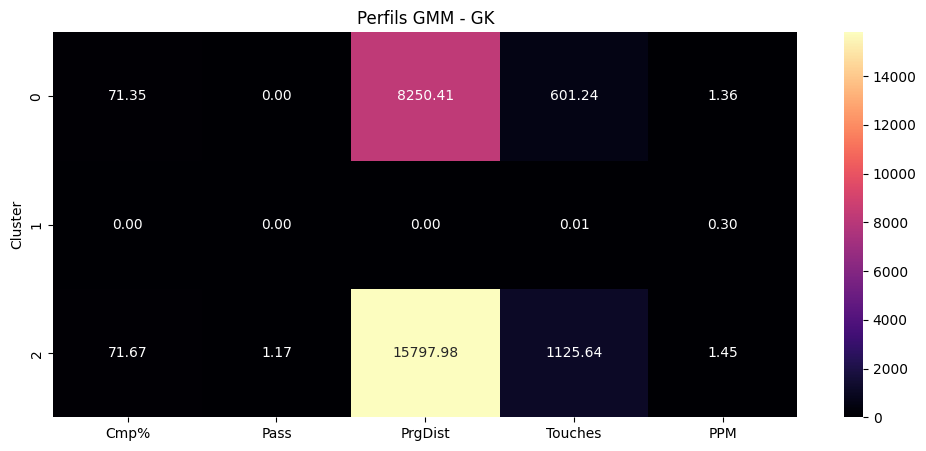


RESUM GLOBAL DE RENDIMENT GMM:
  Posició  Silhouette  Davies-Bouldin  Log-Likelihood
0      DF    0.349057        0.885675        9.681764
1      MF    0.328138        0.809500        4.819584
2      FW    0.129174        1.505812       10.838774
3      GK    0.551267        0.754615       10.655082


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Configuració de mètriques per posició
FEATURES_BY_POS = {
    'df': ['Tkl', 'TklW', 'Int', 'Blocks', 'Clr', 'Won', 'Won%', 'Def 3rd', 'Mid 3rd', 'PrgP', 'PrgDist', 'Cmp%'],
    'mf': ['Pass', 'Cmp%', 'KP', 'xA', 'xAG', 'PPA', 'PrgP', 'PrgC', 'Mid 3rd', 'Att 3rd', 'Recov', 'Sw', 'SCA'],
    'fw': ['Gls', 'Sh', 'SoT', 'G/Sh', 'xG', 'npxG', 'Att Pen', 'Att 3rd', 'PrgR', 'SCA', 'Ast', 'CPA'],
    'gk': ['Cmp%', 'Pass', 'PrgDist', 'Touches', 'PPM']
}

def plot_bic(X_scaled, pos):
    """Calcula el BIC per trobar el nombre òptim de components."""
    bics = []
    n_components_range = range(2, 11)
    for n in n_components_range:
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(X_scaled)
        bics.append(gmm.bic(X_scaled))
    
    plt.figure(figsize=(8, 4))
    plt.plot(n_components_range, bics, 'o-', color='purple')
    plt.title(f'Criteri BIC per a {pos.upper()} (Mínim és millor)')
    plt.xlabel('Nombre de components')
    plt.ylabel('BIC')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pca_gmm(df, pos, title, cluster_col=None):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x='PCA1', y='PCA2', hue=cluster_col, palette='magma' if cluster_col else None, alpha=0.7)
    plt.title(f"GMM 2D - {pos.upper()} - {title}")
    plt.show()

# --- Procés principal ---

df_raw = pd.read_csv('../data/processed/final_dataset_cleaned.csv')
df_raw['Pos_Main'] = df_raw['Pos'].str.split(',').str[0].str.lower()

results_summary = []

for pos, metrics in FEATURES_BY_POS.items():
    pos_df = df_raw[df_raw['Pos_Main'] == pos].copy()
    if len(pos_df) < 15: continue

    X = pos_df[metrics].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)

    # 1. Trobar K òptima amb BIC
    plot_bic(X_scaled, pos)

    # 2. PCA per visualització
    pca = PCA(n_components=3)
    pca_res = pca.fit_transform(X_scaled)
    pos_df['PCA1'], pos_df['PCA2'], pos_df['PCA3'] = pca_res[:,0], pca_res[:,1], pca_res[:,2]

    # 3. Clustering GMM (usem 3 o el que digui el BIC)
    n_clusters = 3
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    pos_df['Cluster'] = gmm.fit_predict(X_scaled)
    
    # 4. Probabilitats (Interessant en GMM: com de segur està el model)
    probs = gmm.predict_proba(X_scaled)
    pos_df['Cluster_Prob'] = probs.max(axis=1)

    # 5. Avaluació
    sil = silhouette_score(X_scaled, pos_df['Cluster'])
    ch = calinski_harabasz_score(X_scaled, pos_df['Cluster'])
    db = davies_bouldin_score(X_scaled, pos_df['Cluster'])

    results_summary.append({
        'Posició': pos.upper(),
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Log-Likelihood': gmm.score(X_scaled) # Mètrica específica de GMM
    })

    # 6. Visualització
    plot_pca_gmm(pos_df, pos, f"Clustering GMM (K={n_clusters})", cluster_col='Cluster')
    
    # Heatmap de perfils
    cluster_profile = pos_df.groupby('Cluster')[metrics].mean()
    plt.figure(figsize=(12, 5))
    sns.heatmap(cluster_profile, annot=True, cmap="magma", fmt=".2f")
    plt.title(f"Perfils GMM - {pos.upper()}")
    plt.show()

df_metrics = pd.DataFrame(results_summary)
print("\nRESUM GLOBAL DE RENDIMENT GMM:")
print(df_metrics)